# Connect google Drive
* Data has been uploaded to google drive ,so we load the drive to have access to the data

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importing  Libaries
* Pandas = to load the datastet
* matplotlib = to help with visualization of the data
* seaboarn = to help with advanced visualization


In [1]:
import pandas as pd # load data
import matplotlib.pyplot as plt # visualize data
import seaborn as sns # advanced visualization of data
print("All Libaries Loaded")


All Libaries Loaded


# Load the dataset
* dataset is loaded from the google drive and stored in variable data


In [2]:
data = pd.read_csv("student_admission_record_dirty.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


# Basic Insights on the data
* shape = to know the size of the data in terms of rows and columns
* columns = to see the column names
* head / tail = to see the first 5 and last 5 data points in the data
* missing values = finding missing values and handling them
* droping duplicates
* info
* decribe

In [3]:
# shape
data.shape
print("The data has {} rows and {} columns".format(data.shape[0],data.shape[1]))

The data has 157 rows and 7 columns


In [4]:
# columns
data.columns
print("The columns in the data are {}".format(data.columns))

The columns in the data are Index(['Name', 'Age', 'Gender', 'Admission Test Score',
       'High School Percentage', 'City', 'Admission Status'],
      dtype='object')


In [5]:
# head
data.head()

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN


In [6]:
# tail
data.tail()

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
152,Ali,19.0,Female,85.0,78.09,Quetta,Accepted
153,Bilal,17.0,Female,81.0,84.40,Islamabad,Rejected
154,Fatima,21.0,Female,98.0,50.86,Multan,Accepted
155,Shoaib,-1.0,Male,91.0,80.12,Quetta,Accepted
156,Maaz,17.0,Male,88.0,86.85,Lahore,Accepted


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    147 non-null    object 
 1   Age                     147 non-null    float64
 2   Gender                  147 non-null    object 
 3   Admission Test Score    146 non-null    float64
 4   High School Percentage  146 non-null    float64
 5   City                    147 non-null    object 
 6   Admission Status        147 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.7+ KB


In [8]:
data.describe()

,Age,Admission Test Score,High School Percentage
count,147.000000,146.000000,146.000000
mean,19.680272,77.657534,75.684726
std,4.540512,16.855343,17.368014
min,-1.000000,-5.000000,-10.000000
25%,18.000000,68.250000,65.052500
50%,20.000000,79.000000,77.545000
75%,22.000000,89.000000,88.312500
max,24.000000,150.000000,110.500000


In [9]:
# missing values
data.isnull().sum()

Name                      10
Age                       10
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

* There are missing values in the dataset,
* Dataset has 157 data points, droping missing values will reduce the size of the datapoints and so we handle all missing values

## Handling missing values
* filling the missing values in the name column with Ken
* filling the missing values on AGe with  the mean age
* filling the missing values in the gender with the mode
* filling the missing values in the admission test score with the average
* filling the missing values in the high schoool percentage with the average
* filling the missing values in the city with the mode
* dele the roles with the missing columns in the admission




In [10]:
# filling name with ken
data['Name'].fillna('Kennedy',inplace=True)

/tmp/ipykernel_92868/2417221849.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Name'].fillna('Kennedy',inplace=True)


In [11]:
data.isna().sum()

Name                       0
Age                       10
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

In [12]:
mean_age = data['Age'].mean()
print(mean_age)
# round the mean_age to two decimal
mean_age = round(mean_age,2)
print(mean_age)

19.68027210884354
19.68


In [13]:
# fill age wiht mean age
data.fillna({"Age":mean_age},inplace=True)

In [14]:
data.isna().sum()

Name                       0
Age                        0
Gender                    10
Admission Test Score      11
High School Percentage    11
City                      10
Admission Status          10
dtype: int64

In [15]:
# poplular value in the gender column
popular_value = data['Gender'].mode()[0]

In [16]:
popular_value

'Female'

In [17]:
# fill gender with mode
data.fillna({"Gender":popular_value},inplace=True)

In [18]:
mean_test_score = data['Admission Test Score'].mean()
print(mean_test_score)

77.65753424657534


In [19]:
# fill addmission test score with the mean
data.fillna({"Admission Test Score":mean_test_score},inplace=True)

In [20]:
mean_high_school_percentage = data['High School Percentage'].mean()
print(mean_high_school_percentage)

75.68472602739726


In [21]:
# fill the high school percentage columns
data.fillna({"High School Percentage":mean_high_school_percentage},inplace=True)

In [22]:
popular_value = data['City'].mode()[0]
print(popular_value)

Quetta


In [23]:
# fill
data.fillna({"City":popular_value},inplace=True)

In [24]:
data.isna().sum()

Name                       0
Age                        0
Gender                     0
Admission Test Score       0
High School Percentage     0
City                       0
Admission Status          10
dtype: int64

In [25]:
# delete the empty columns in the admisson status
data.dropna(subset=['Admission Status'],inplace=True)

In [26]:
data.isna().sum()

Name                      0
Age                       0
Gender                    0
Admission Test Score      0
High School Percentage    0
City                      0
Admission Status          0
dtype: int64

# Explository Data Analysis

In [27]:
data.columns

Index(['Name', 'Age', 'Gender', 'Admission Test Score',
       'High School Percentage', 'City', 'Admission Status'],
      dtype='object')

In [28]:
data['Age']

0      24.0
2      17.0
3      17.0
5      23.0
6      18.0
       ... 
152    19.0
153    17.0
154    21.0
155    -1.0
156    17.0
Name: Age, Length: 147, dtype: float64

In [29]:
# remove all rows with age less than 1
data = data[data['Age']>=1]

In [30]:
data

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.000000,68.900000,Quetta,Rejected
2,Bushra,17.0,Male,89.000000,75.684726,Islamabad,Accepted
3,Aliya,17.0,Male,55.000000,85.290000,Karachi,Rejected
5,Murtaza,23.0,Female,77.657534,75.684726,Islamabad,Accepted
6,Asad,18.0,Male,77.657534,97.310000,Multan,Accepted
...,...,...,...,...,...,...,...
151,Asad,20.0,Female,95.000000,52.400000,Rawalpindi,Rejected
152,Ali,19.0,Female,85.000000,78.090000,Quetta,Accepted
153,Bilal,17.0,Female,81.000000,84.400000,Islamabad,Rejected
154,Fatima,21.0,Female,98.000000,50.860000,Multan,Accepted


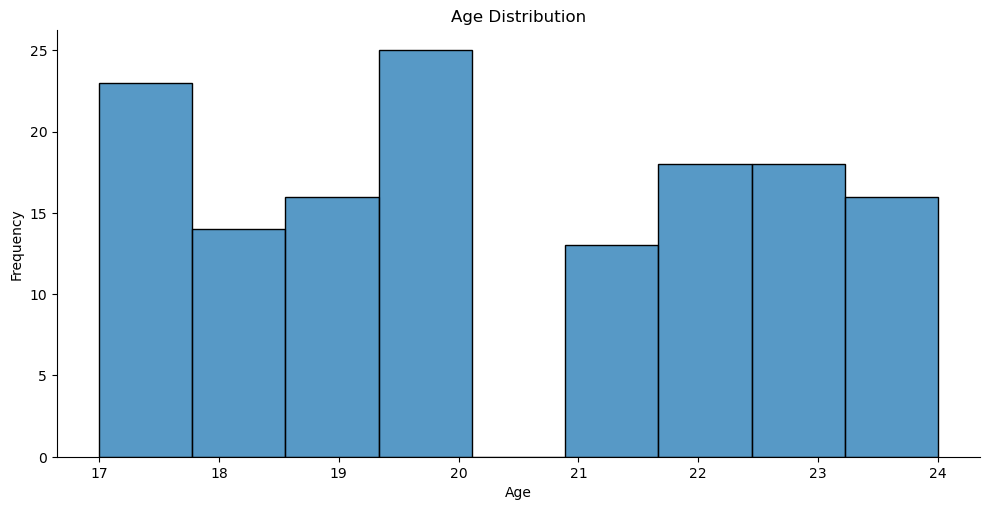

In [31]:
# displot of age
# Using seaborn's displot function, which manages its own figure
sns.displot(data['Age'], height=5, aspect=2)  # height in inches and aspect ratio (width = aspect * height)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


In [32]:
#value count
data['Age'].value_counts()

Age
17.00    23
23.00    18
22.00    18
24.00    16
19.00    16
20.00    15
18.00    14
21.00    13
19.68    10
Name: count, dtype: int64

In [33]:
# Age Information
data['Age'].describe()

count    143.000000
mean      20.355245
std        2.321027
min       17.000000
25%       18.000000
50%       20.000000
75%       22.000000
max       24.000000
Name: Age, dtype: float64

In [34]:
# min and max age
data['Age'].min()
print("The min age is {}".format(data['Age'].min()))

The min age is 17.0


In [35]:
#max age
data['Age'].max()
print("The max age is {}".format(data['Age'].max()))

The max age is 24.0


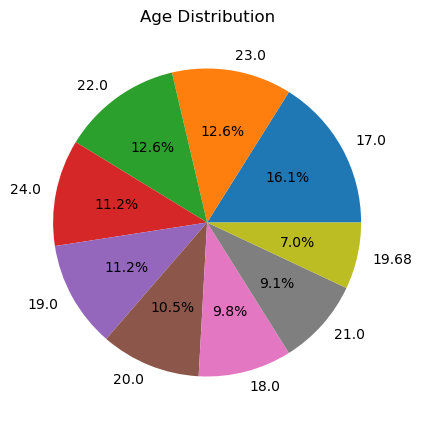

In [36]:
#pie chart of the age
plt.figure(figsize=(5,5))
plt.pie(data['Age'].value_counts(),labels=data['Age'].value_counts().index,autopct='%1.1f%%')
plt.title('Age Distribution')
plt.show()

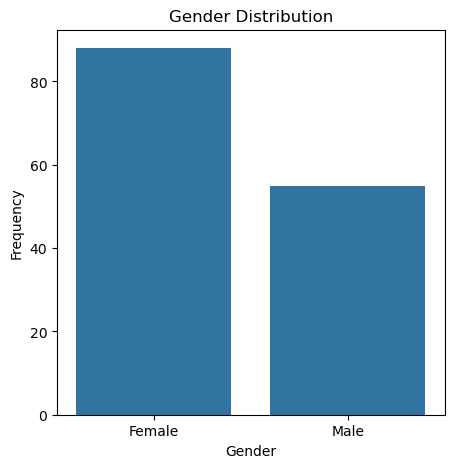

In [37]:
# plot gender
plt.figure(figsize=(5,5))
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Frequency")
sns.countplot(x='Gender',data=data)
plt.show()

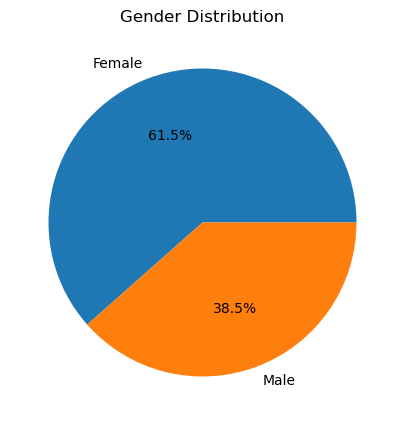

In [38]:
plt.figure(figsize=(5,5))
plt.pie(data['Gender'].value_counts(),labels=data['Gender'].value_counts().index,autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

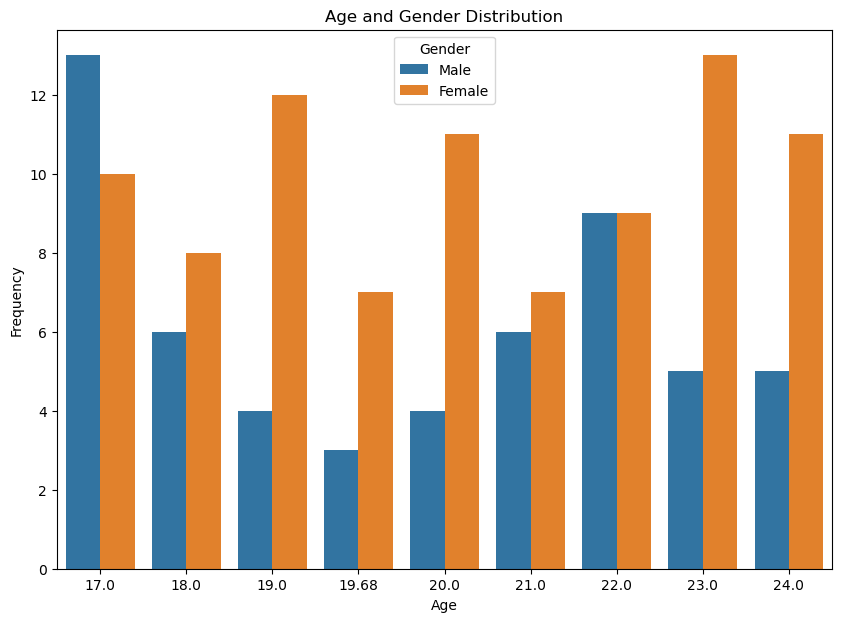

In [39]:
#age and gender
plt.figure(figsize=(10,7))
plt.title("Age and Gender Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
sns.countplot(x='Age',hue='Gender',data=data)
plt.show()


In [40]:
# groupby age- gender
data.groupby(['Age','Gender']).size()

Age    Gender
17.00  Female    10
       Male      13
18.00  Female     8
       Male       6
19.00  Female    12
       Male       4
19.68  Female     7
       Male       3
20.00  Female    11
       Male       4
21.00  Female     7
       Male       6
22.00  Female     9
       Male       9
23.00  Female    13
       Male       5
24.00  Female    11
       Male       5
dtype: int64

In [41]:
# youngest girl age and oldest girl age
youngest_girl_age = data[data['Gender']=='Female']['Age'].min()
print("The youngest girl age is {}".format(youngest_girl_age))




The youngest girl age is 17.0


In [42]:
# oldest girl age
oldest_girl_age = data[data['Gender']=='Female']['Age'].max()
print("The oldest girl age is {}".format(oldest_girl_age))


The oldest girl age is 24.0


In [43]:
# average girl age
average_girl_age = data[data['Gender']=='Female']['Age'].mean()
print("The average girl age is {}".format(average_girl_age))

The average girl age is 20.542727272727276


In [44]:
# youngest boy age
youngest_boy_age = data[data['Gender']=='Male']['Age'].min()
print("The youngest boy age is {}".format(youngest_boy_age))

The youngest boy age is 17.0


In [45]:
# oldest boy age
oldest_boy_age = data[data['Gender']=='Male']['Age'].max()
print("The oldest boy age is {}".format(oldest_boy_age))
#

The oldest boy age is 24.0


In [46]:
# average boy age
average_boy_age = data[data['Gender']=='Male']['Age'].mean()
print("The average boy age is {}".format(average_boy_age))

The average boy age is 20.05527272727273


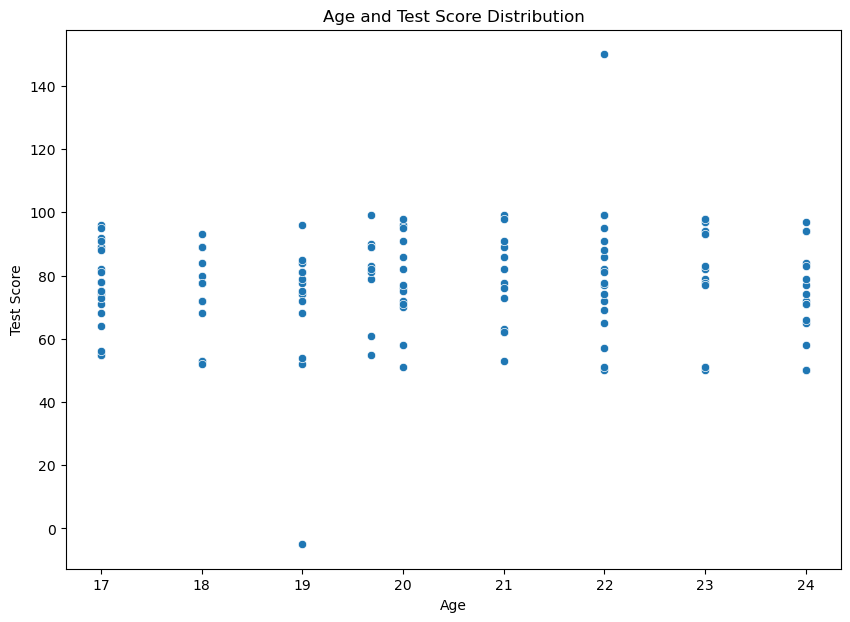

In [47]:
# Age and test score
plt.figure(figsize=(10,7))
plt.title("Age and Test Score Distribution")
plt.xlabel("Age")
plt.ylabel("Test Score")
sns.scatterplot(x='Age',y='Admission Test Score',data=data)
plt.show()

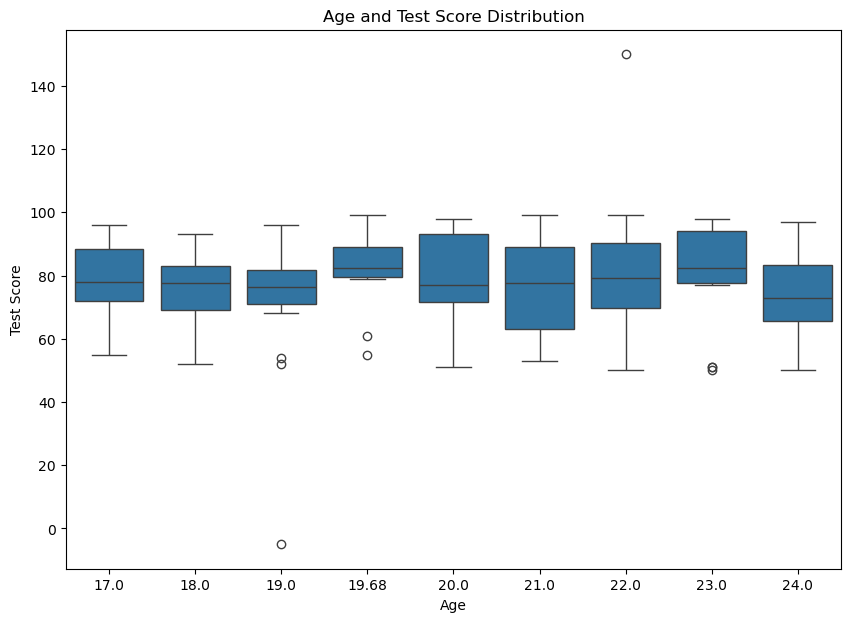

In [48]:
# age and test score
plt.figure(figsize=(10,7))
plt.title("Age and Test Score Distribution")
plt.xlabel("Age")
plt.ylabel("Test Score")
sns.boxplot(x='Age',y='Admission Test Score',data=data)
plt.show()

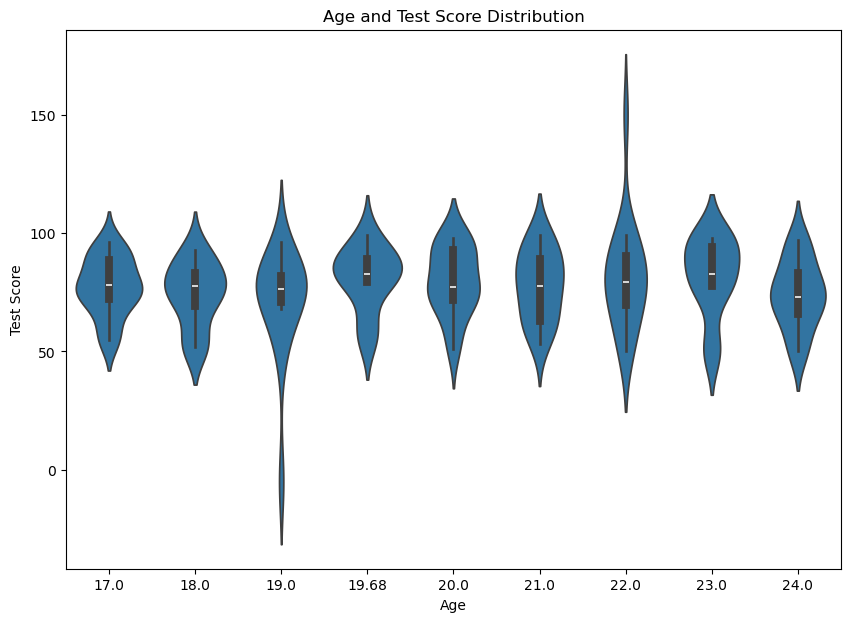

In [49]:
# age and test score distribution
plt.figure(figsize=(10,7))
plt.title("Age and Test Score Distribution")
plt.xlabel("Age")
plt.ylabel("Test Score")
sns.violinplot(x='Age',y='Admission Test Score',data=data)
plt.show()

In [50]:
# least test score
least_test_score = data['Admission Test Score'].min()
print("The least test score is {}".format(least_test_score))

The least test score is -5.0


In [51]:
# highest test score
highest_test_score = data['Admission Test Score'].max()
print("The highest test score is {}".format(highest_test_score))

The highest test score is 150.0


In [52]:
# averagge test scorw
average_test_score = data['Admission Test Score'].mean()
print("The average test score is {}".format(average_test_score))


The average test score is 77.47494970782641


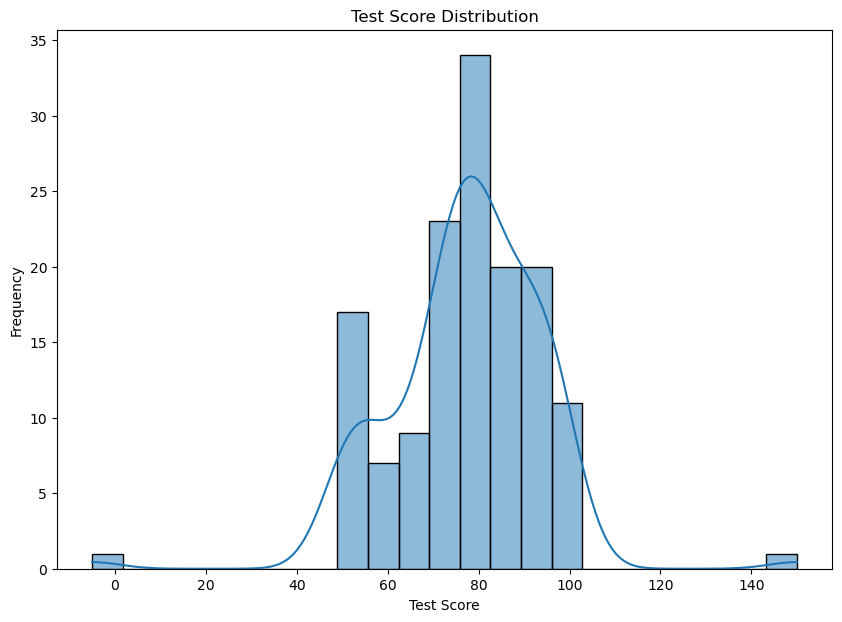

In [53]:
# test score disribution
plt.figure(figsize=(10,7))
plt.title("Test Score Distribution")
plt.xlabel("Test Score")
plt.ylabel("Frequency")
sns.histplot(data['Admission Test Score'],kde=True)
plt.show()

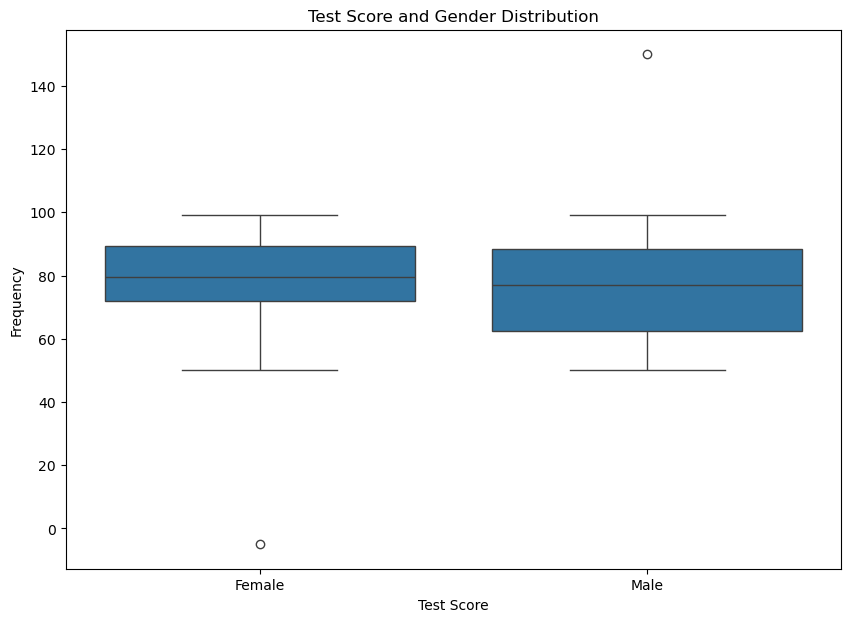

In [54]:
# test score and gender distribution
plt.figure(figsize=(10,7))
plt.title("Test Score and Gender Distribution")
plt.xlabel("Test Score")
plt.ylabel("Frequency")
sns.boxplot(x='Gender',y='Admission Test Score',data=data)
plt.show()

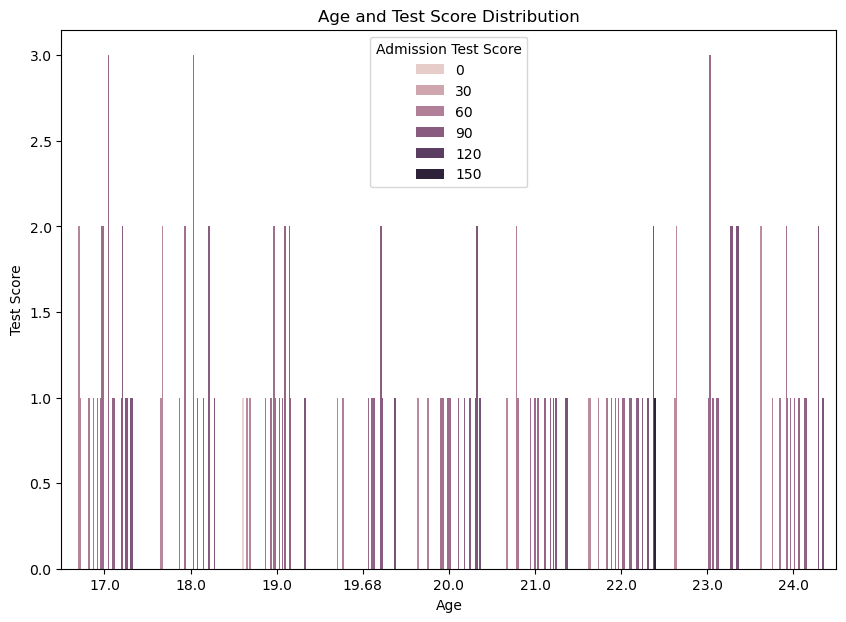

In [55]:
# ccount plot of age and test score
plt.figure(figsize=(10,7))
plt.title("Age and Test Score Distribution")
plt.xlabel("Age")
plt.ylabel("Test Score")
sns.countplot(x='Age',hue='Admission Test Score',data=data)
plt.show()

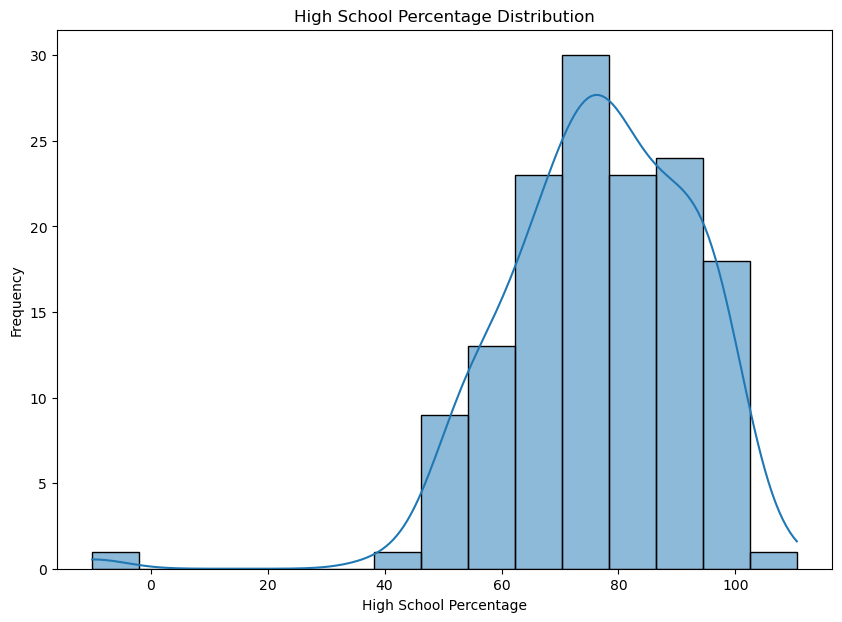

In [56]:
# heigh school distribution
plt.figure(figsize=(10,7))
plt.title("High School Percentage Distribution")
plt.xlabel("High School Percentage")
plt.ylabel("Frequency")
sns.histplot(data['High School Percentage'],kde=True)
plt.show()

In [57]:
#least highschool percentage
least_highschool_percentage = data['High School Percentage'].min()
print("The least highschool percentage is {}".format(least_highschool_percentage))

The least highschool percentage is -10.0


In [58]:
# highest high school percentafe
highest_highschool_percentage = data['High School Percentage'].max()
print("The highest highschool percentage is {}".format(highest_highschool_percentage))

The highest highschool percentage is 110.5


In [59]:
# group by gender and high school percentage
data.groupby('Gender')['High School Percentage'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,88.0,74.532709,13.936144,40.7,65.397500,74.465,83.915,110.50
Male,55.0,80.322066,18.158165,-10.0,75.684726,84.640,92.505,98.98


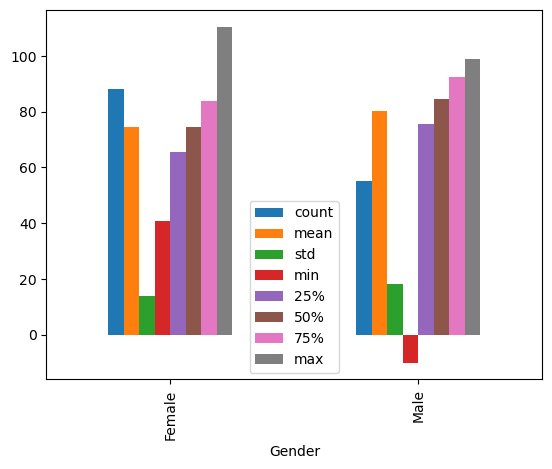

In [60]:
data.groupby('Gender')['High School Percentage'].describe().plot(kind='bar')
plt.show()

In [61]:
# correlation of age ,test score, high school
columns_to_check = ['Age','Admission Test Score','High School Percentage']
correlation_matrix = data[columns_to_check].corr()
print(correlation_matrix)

                             Age  Admission Test Score  High School Percentage
Age                     1.000000              0.065229                0.165767
Admission Test Score    0.065229              1.000000               -0.111064
High School Percentage  0.165767             -0.111064                1.000000


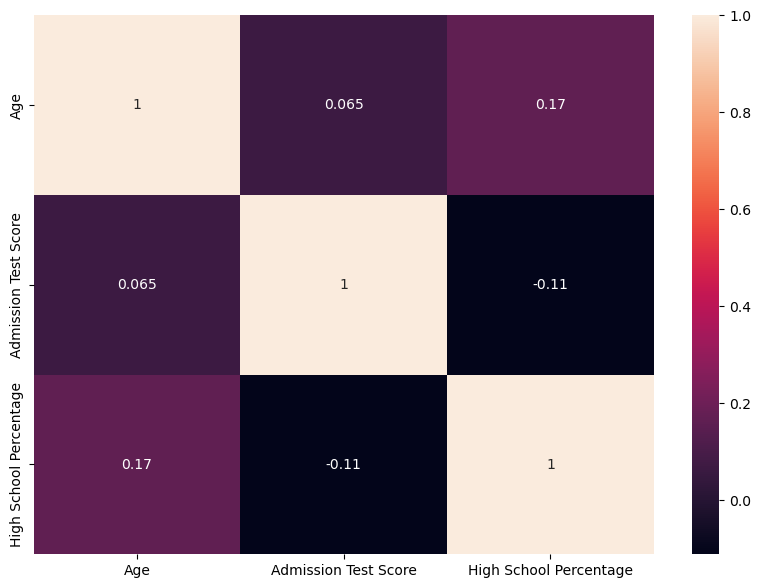

In [62]:
# plot
plt.figure(figsize=(10,7))
sns.heatmap(correlation_matrix,annot=True)
plt.show()



* Age and Admission Test Score: The value 0.065229 suggests a very weak positive correlation between age and admission test scores. This means that as age increases, there is a slightly positive tendency for admission test scores to increase as well, but the effect is very minimal.

* Age and High School Percentage: The value 0.165767 indicates a weak positive correlation between age and high school percentage. This implies that older students might tend to have slightly higher high school percentages, but again, this relationship is weak.

* Admission Test Score and Age: As mentioned, this is 0.065229, reflecting a very weak positive correlation, mirroring the relationship from the perspective of how admission test scores relate to age.


* Admission Test Score and High School Percentage: The value -0.111064 shows a weak negative correlation. This suggests that higher admission test scores might slightly correlate with lower high school percentages, but the relationship is weak and might not be statistically significant or practically meaningful.

* High School Percentage and Age: This correlation of 0.165767 is the same as when viewed from age to high school percentage, showing a weak positive relationship.

* High School Percentage and Admission Test Score: The -0.111064 correlation is again mentioned, showing a weak negative relationship.



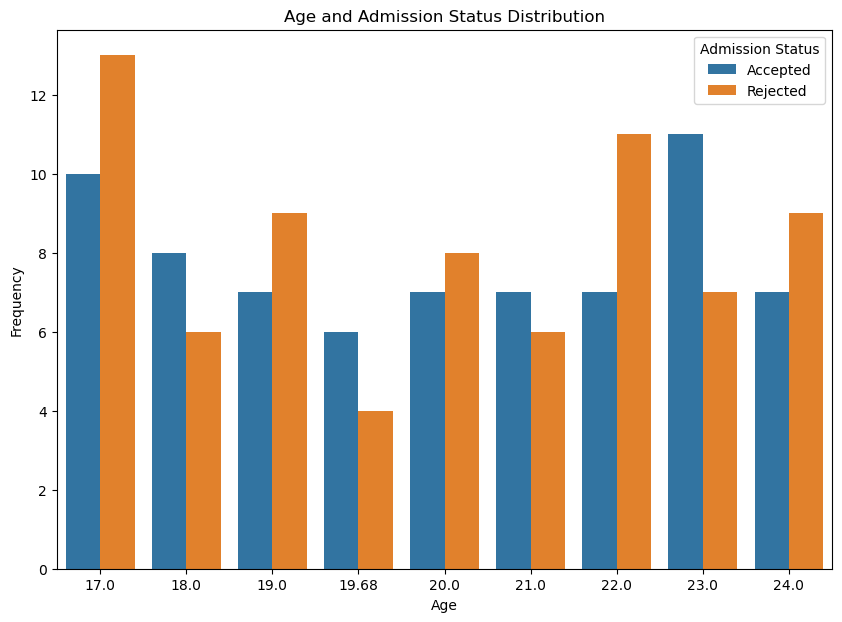

In [63]:
# age and Admission status
plt.figure(figsize=(10,7))
plt.title("Age and Admission Status Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
sns.countplot(x='Age',hue='Admission Status',data=data)
plt.show()

In [64]:
# age and admission status groupby
data.groupby(['Age','Admission Status']).size()

Age    Admission Status
17.00  Accepted            10
       Rejected            13
18.00  Accepted             8
       Rejected             6
19.00  Accepted             7
       Rejected             9
19.68  Accepted             6
       Rejected             4
20.00  Accepted             7
       Rejected             8
21.00  Accepted             7
       Rejected             6
22.00  Accepted             7
       Rejected            11
23.00  Accepted            11
       Rejected             7
24.00  Accepted             7
       Rejected             9
dtype: int64

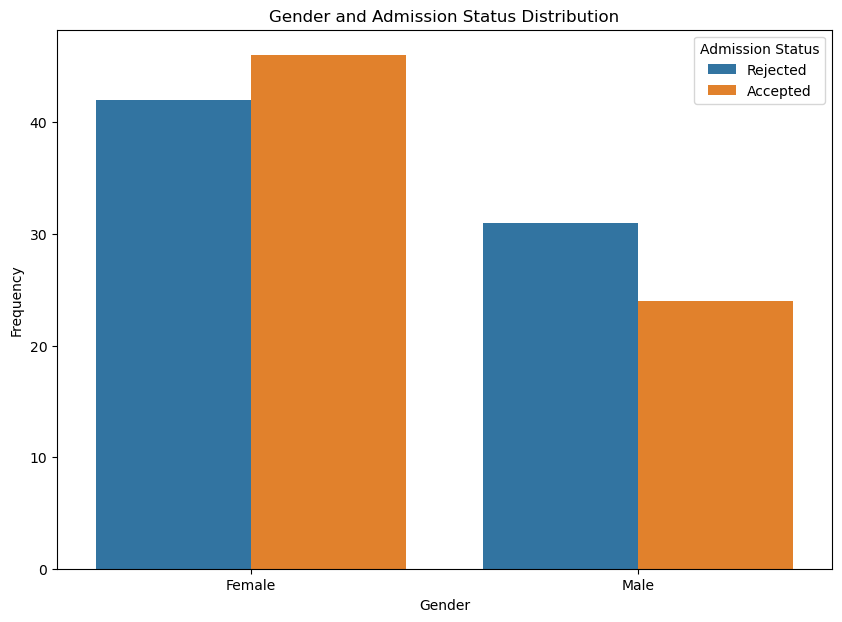

In [65]:
# gender and admission status
plt.figure(figsize=(10,7))
plt.title("Gender and Admission Status Distribution")
plt.xlabel("Gender")
plt.ylabel("Frequency")
sns.countplot(x='Gender',hue='Admission Status',data=data)
plt.show()


Text(0.5, 1.0, 'Admission Status Distribution')

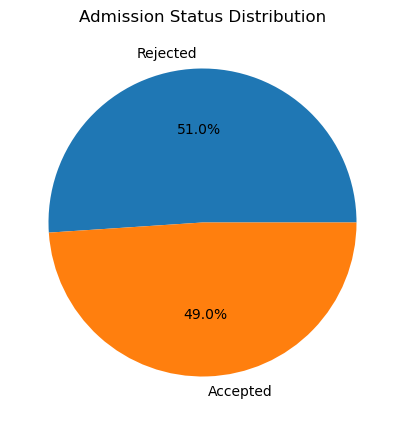

In [66]:
# piechart of admission status
plt.figure(figsize=(5,5))
plt.pie(data['Admission Status'].value_counts(),labels=data['Admission Status'].value_counts().index,autopct='%1.1f%%')
plt.title('Admission Status Distribution')


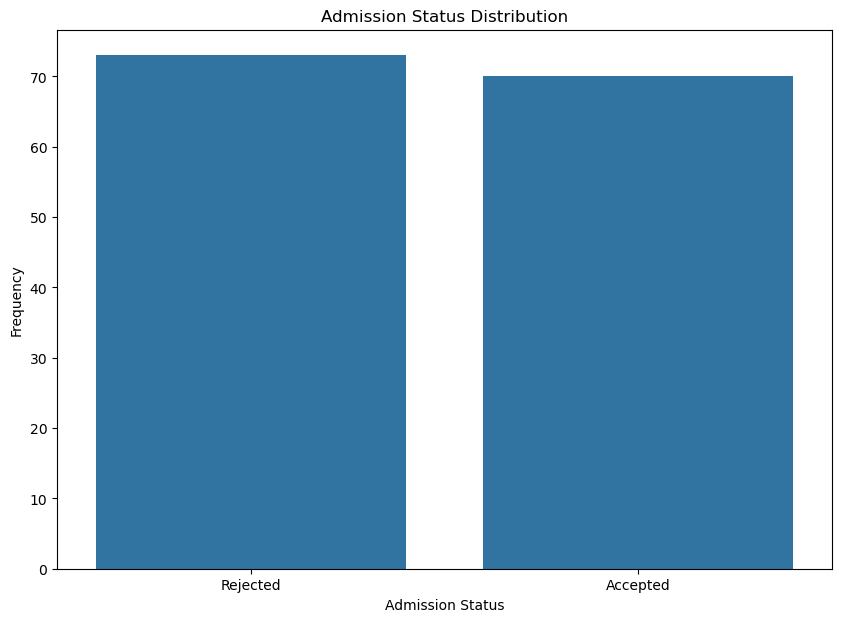

In [67]:
# plot admission status
plt.figure(figsize=(10,7))
plt.title("Admission Status Distribution")
plt.xlabel("Admission Status")
plt.ylabel("Frequency")
sns.countplot(x='Admission Status',data=data)
plt.show()

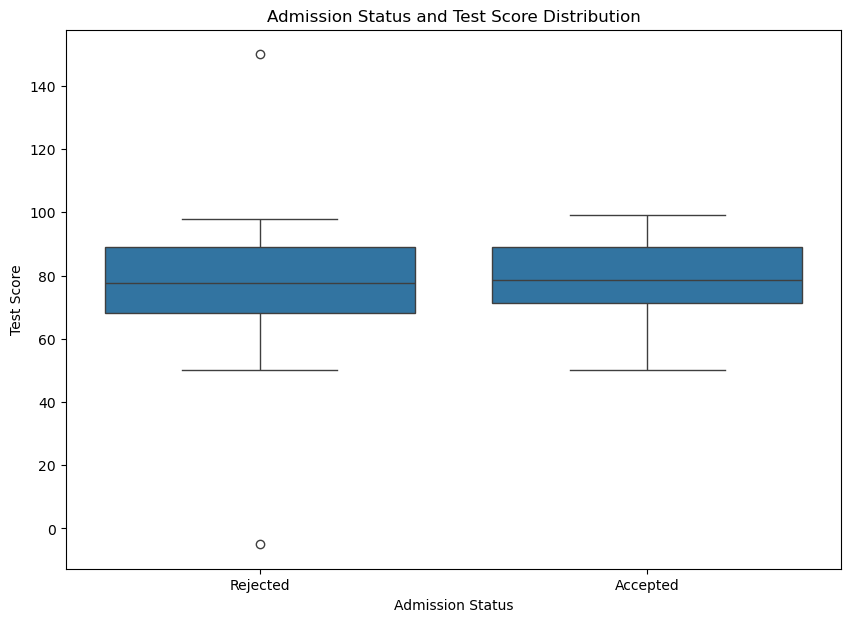

In [68]:
# admission status and test score
plt.figure(figsize=(10,7))
plt.title("Admission Status and Test Score Distribution")
plt.xlabel("Admission Status")
plt.ylabel("Test Score")
sns.boxplot(x='Admission Status',y='Admission Test Score',data=data)
plt.show()

In [69]:
# group by test and status
data.groupby(['Admission Status','Admission Test Score']).size()

Admission Status  Admission Test Score
Accepted          50.0                    2
                  51.0                    2
                  52.0                    2
                  54.0                    1
                  57.0                    1
                                         ..
Rejected          95.0                    3
                  96.0                    4
                  97.0                    2
                  98.0                    2
                  150.0                   1
Length: 73, dtype: int64

In [70]:
# save cleaned data
data.to_csv("/content/drive/My Drive/student_admission_record_cleaned.csv",index=False)
print("Data saved successfully")

OSError: Cannot save file into a non-existent directory: '/content/drive/My Drive'

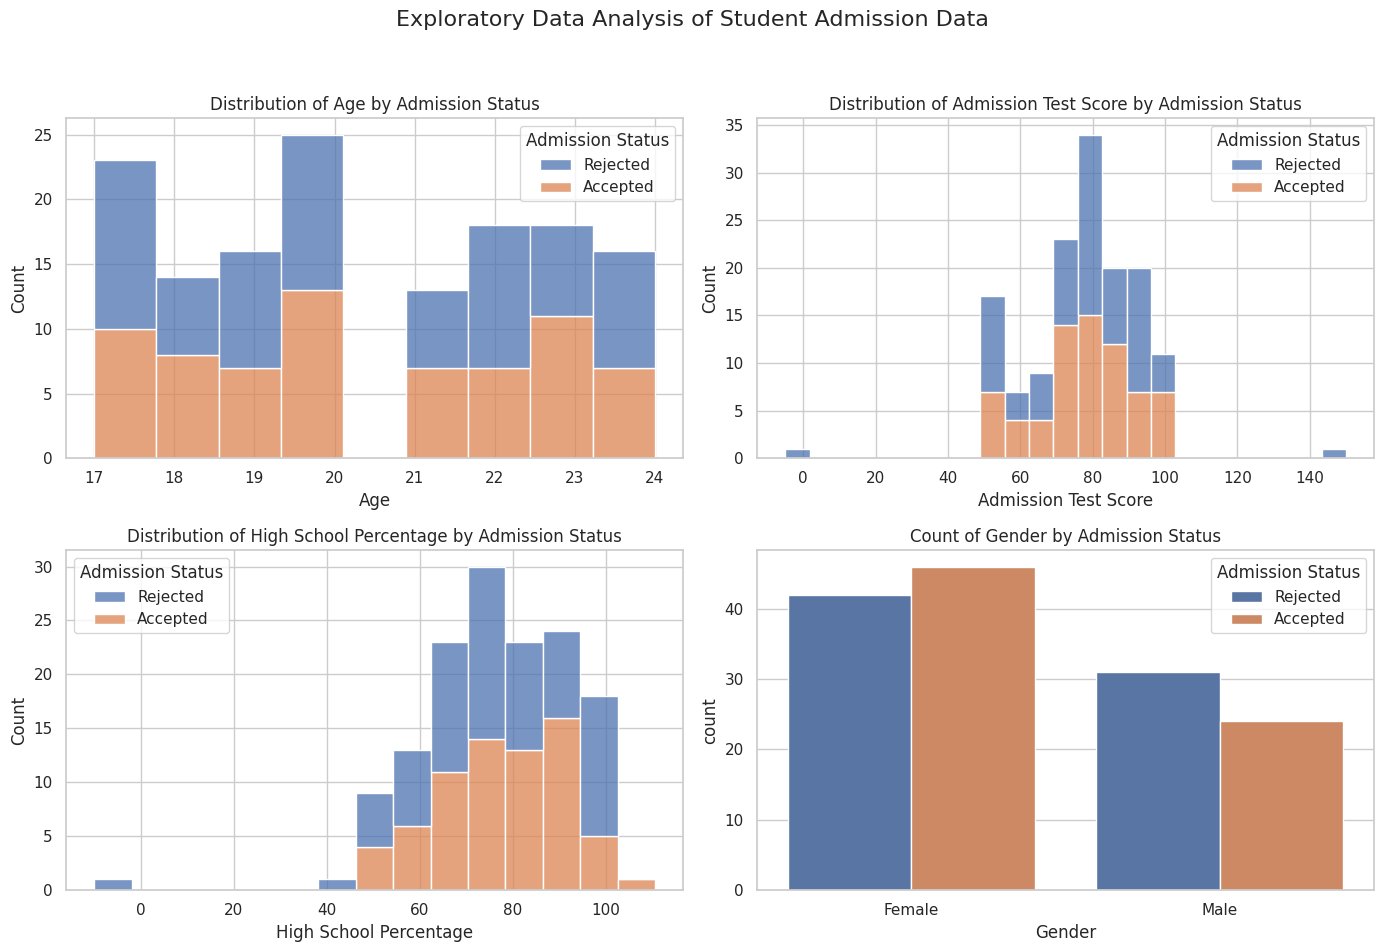

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the aesthetic style for the plots
sns.set(style="whitegrid")

# Creating a figure to contain the plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis of Student Admission Data', fontsize=16)

# Plotting histograms and count plots
sns.histplot(data=data, x='Age', hue='Admission Status', multiple="stack", ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age by Admission Status')

sns.histplot(data=data, x='Admission Test Score', hue='Admission Status', multiple="stack", ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Admission Test Score by Admission Status')

sns.histplot(data=data, x='High School Percentage', hue='Admission Status', multiple="stack", ax=axes[1, 0])
axes[1, 0].set_title('Distribution of High School Percentage by Admission Status')

sns.countplot(data=data, x='Gender', hue='Admission Status', ax=axes[1, 1])
axes[1, 1].set_title('Count of Gender by Admission Status')

# Adjusting layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Displaying the plots
plt.show()


In [ ]:
data.isna().sum()

,0
Name,0
Age,0
Gender,0
Admission Test Score,0
High School Percentage,0
City,0
Admission Status,0


In [ ]:
data

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.000000,68.900000,Quetta,Rejected
2,Bushra,17.0,Male,89.000000,75.684726,Islamabad,Accepted
3,Aliya,17.0,Male,55.000000,85.290000,Karachi,Rejected
5,Murtaza,23.0,Female,77.657534,75.684726,Islamabad,Accepted
6,Asad,18.0,Male,77.657534,97.310000,Multan,Accepted
...,...,...,...,...,...,...,...
151,Asad,20.0,Female,95.000000,52.400000,Rawalpindi,Rejected
152,Ali,19.0,Female,85.000000,78.090000,Quetta,Accepted
153,Bilal,17.0,Female,81.000000,84.400000,Islamabad,Rejected
154,Fatima,21.0,Female,98.000000,50.860000,Multan,Accepted


# Preparing data for Prediction

## removing out liers in the Age, Admission Test Score, 	High School Percentage

In [ ]:
# detecting outliers in Age
Q1 = data['Age'].quantile(0.25)
Q3 = data['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['Age'] < lower_bound) | (data['Age'] > upper_bound)]
print("Outliers in Age:")
print(len(outliers))

Outliers in Age:
0


In [ ]:
# detecting outlier in admission test score
Q1 = data['Admission Test Score'].quantile(0.25)
Q3 = data['Admission Test Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['Admission Test Score'] < lower_bound) | (data['Admission Test Score'] > upper_bound)]
print("Outliers in Admission Test Score:")
print(len(outliers))

Outliers in Admission Test Score:
2


In [ ]:
# droping the outliers from the data
data = data[(data['Admission Test Score'] >= lower_bound) & (data['Admission Test Score'] <= upper_bound)]

In [ ]:
# detecting outliers in high school percentage
Q1 = data['High School Percentage'].quantile(0.25)
Q3 = data['High School Percentage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['High School Percentage'] < lower_bound) | (data['High School Percentage'] > upper_bound)]
print("Outliers in High School Percentage:")
print(len(outliers))

Outliers in High School Percentage:
1


In [ ]:
# droping the outliers from the data
data = data[(data['High School Percentage'] >= lower_bound) & (data['High School Percentage'] <= upper_bound)]

In [ ]:
data.shape

(140, 7)

## Preparing Data



In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder


In [72]:
# drop the Name column
data.drop(columns=['Name'],inplace=True)

In [73]:
y_target = data['Admission Status']

In [74]:
data.drop(columns=['Admission Status'],inplace=True)


In [75]:
# label encode Gender
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])

In [76]:
data

,Age,Gender,Admission Test Score,High School Percentage,City
0,24.0,0,50.000000,68.900000,Quetta
2,17.0,1,89.000000,75.684726,Islamabad
3,17.0,1,55.000000,85.290000,Karachi
5,23.0,0,77.657534,75.684726,Islamabad
6,18.0,1,77.657534,97.310000,Multan
...,...,...,...,...,...
151,20.0,0,95.000000,52.400000,Rawalpindi
152,19.0,0,85.000000,78.090000,Quetta
153,17.0,0,81.000000,84.400000,Islamabad
154,21.0,0,98.000000,50.860000,Multan


In [77]:
# label encode admission status
label_encoder = LabelEncoder()
y_target = label_encoder.fit_transform(y_target)

In [82]:

y_target


array([1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0])

In [83]:
# one hot encode the city column
# one hot encode
one_hot_encoder = OneHotEncoder()
city_encoded = one_hot_encoder.fit_transform(data[['City']])

In [84]:

# Convert the sparse matrix to a DataFrame
encoded_df = pd.DataFrame(
    city_encoded.toarray(),
    columns=one_hot_encoder.get_feature_names_out(['City'])  # This ensures column names are meaningful
)


In [85]:
encoded_df

,City_Islamabad,City_Karachi,City_Lahore,City_Multan,City_Peshawar,City_Quetta,City_Rawalpindi
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
138,0.0,0.0,0.0,0.0,0.0,0.0,1.0
139,0.0,0.0,0.0,0.0,0.0,1.0,0.0
140,1.0,0.0,0.0,0.0,0.0,0.0,0.0
141,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [86]:
data = data.drop('City', axis=1)

In [87]:
data = pd.concat([data, encoded_df], axis=1)

In [88]:
data.head()

,Age,Gender,Admission Test Score,High School Percentage,City_Islamabad,City_Karachi,City_Lahore,City_Multan,City_Peshawar,City_Quetta,City_Rawalpindi
0,24.0,0.0,50.000000,68.900000,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,17.0,1.0,89.000000,75.684726,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,17.0,1.0,55.000000,85.290000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,23.0,0.0,77.657534,75.684726,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,18.0,1.0,77.657534,97.310000,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# Predictive Model

In [89]:
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier


In [90]:
data = data.iloc[:len(y_target), :]

In [91]:
X_train, X_test, y_train, y_test = train_test_split(data, y_target, test_size=0.2, random_state=42)

In [92]:
X_train.shape

(114, 11)

In [93]:
X_test.shape

(29, 11)

In [94]:
y_train.shape

(114,)

In [95]:
y_test.shape

(29,)

In [96]:
dtc = DecisionTreeClassifier()

In [97]:
dtc_model = dtc.fit(X_train,y_train)

In [98]:
dtc_model

DecisionTreeClassifier()

# Model Evaluation

In [99]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [100]:
accuracy_score = accuracy_score(y_test, dtc_model.predict(X_test))
print("Accuracy Score:", accuracy_score)

Accuracy Score: 0.4827586206896552


In [101]:
confusion_matrix = confusion_matrix(y_test, dtc_model.predict(X_test))
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[5 6]
 [9 9]]


# Summary Report

## Choice of Model
* The model chosen for the challenge is a Decision Tree Classifier. This is a popular choice for classification jobs because of the model's capacity to handle both numerical and categorical data, as well as its interpretability. Decision trees are simple to understand and depict, thus they are a common choice for initial modeling and research.

## Model’s Performance
* The model has an accuracy of 50%
* according to the confusion matrix report, the model predocted 5 true posives and 6 false positives for accepted
* also the model predicted 7 false positives for students not admitted abd 10 true positves,

## Potential Ways to Improve
* Hyperparameter Tuning: Decision Trees have several parameters (like max_depth, min_samples_split, and min_samples_leaf) that can have a considerable impact on their performance. Using strategies such as grid search or random search to adjust these settings may produce better results.

* Ensemble Methods: serveral models can be combined to build a predictive model

* Alternative Models: Experimenting with other model


# Deploying the Model

In [102]:
import joblib

# Assuming 'dtc_model' is your trained Decision Tree Classifier
joblib.dump(dtc_model, 'dtc_model.joblib')


['dtc_model.joblib']

In [103]:
# # deploy model with streamlit
# import streamlit as st
# import pandas as pd
# import joblib

# # Load your trained model
# model = joblib.load('dtc_model.joblib')

# # Creating a simple Streamlit application
# st.title('Student Admission Prediction')

# # Getting user input
# st.subheader('Please enter the following details:')

# age = st.number_input('Age', min_value=1, max_value=100, value=25)
# test_score = st.slider('Admission Test Score', 0, 100, 50)
# high_school_percentage = st.slider('High School Percentage', 0.0, 100.0, 50.0)
# gender = st.selectbox('Gender', ['Male', 'Female'])
# city = st.selectbox('City', ['City1', 'City2', 'City3']) # Adjust city options based on your dataset

# # When 'Predict' button is clicked
# if st.button('Predict'):
#     # Prepare the input data
#     input_data = pd.DataFrame({
#         'Age': [age],
#         'Admission Test Score': [test_score],
#         'High School Percentage': [high_school_percentage],
#         'Gender': [gender],
#         'City': [city]
#     })

#     # Assuming the input needs to be encoded or preprocessed (you need to handle this based on your model)
#     # You would typically load a preprocessing pipeline here

#     # For simplicity, assume we just use the model directly here
#     prediction = model.predict(input_data)

#     # Display the prediction
#     result = 'Admitted' if prediction[0] == 1 else 'Not Admitted'
#     st.success(f'The prediction is: {result}')




2025-01-15 09:19:19.168 
  command:

    streamlit run /home/akogo/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
